# Segmentación de Clientes Bancarios con K-Means

## Objetivo

Este notebook aplica el algoritmo **K-Means** para segmentar la cartera de clientes de un banco en grupos homogéneos.  
El resultado es una **etiqueta de cluster** por cliente que luego puede usarse para:

- Personalizar campañas de marketing
- Priorizar esfuerzos comerciales
- Entender patrones de comportamiento financiero

## Fuentes de datos

| Archivo | Contenido |
|---|---|
| `procesado_bi_customer_products.csv` | Productos contratados por cliente y partición temporal |
| `procesado_bi_customer_sociodemographics.csv` | Perfil demográfico (edad, género, salario, segmento…) |
| `product_description.csv` | Catálogo de productos |
| `sales.csv` | Ventas realizadas con su margen neto |
| `procesado_df_commercial_clean.csv` | Actividad comercial y fecha de alta del cliente |

## Variables usadas en el clustering

- **Perfil sociodemográfico**: edad, salario, segmento
- **Actividad comercial**: cliente activo/inactivo, antigüedad en meses
- **Portafolio de productos**: 15 tipos de productos contratados + total
- **Rentabilidad**: margen neto acumulado de ventas

## Flujo del notebook

```
Carga de datos → Preparación (última partición por cliente) → Unión →
Imputación de nulos → Escalado → K-Means (k=7) → Análisis de resultados
```

---
## 1. Importación de librerías

- **pandas / numpy**: manipulación y cálculo sobre datos tabulares
- **matplotlib**: visualizaciones
- **StandardScaler**: normaliza las variables a media 0 y desviación estándar 1 — imprescindible para K-Means, que es sensible a la escala
- **KMeans**: algoritmo de clustering
- **KNNImputer**: imputa valores faltantes usando los k vecinos más cercanos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer

---
## 2. Carga de datos

Cargamos los cinco datasets en DataFrames independientes.  
Más adelante los uniremos por la clave de cliente `pk_cid`.

In [ ]:
df_customer         = pd.read_csv('procesado_bi_customer_products.csv')
df_sociodemographic = pd.read_csv('procesado_bi_customer_sociodemographics.csv')
df_product          = pd.read_csv('product_description.csv', index_col=0)
df_sales            = pd.read_csv('sales.csv', index_col=0)
df_commercial       = pd.read_csv('procesado_df_commercial_clean.csv')

# Vista rápida del tamaño de cada fuente
for name, df in [
    ('customer_products', df_customer),
    ('sociodemographics', df_sociodemographic),
    ('product_description', df_product),
    ('sales', df_sales),
    ('commercial', df_commercial),
]:
    print(f'{name:25s}  {df.shape[0]:>8,} filas  ×  {df.shape[1]:>3} columnas')

customer_products          5,962,924 filas  ×   17 columnas
sociodemographics          5,962,924 filas  ×    8 columnas
product_description              13 filas  ×    3 columnas
sales                       240,773 filas  ×    5 columnas
commercial                 5,962,924 filas  ×    6 columnas


---
## 3. Preparación de datos

Los datasets de productos, sociodemografía y actividad comercial tienen **múltiples filas por cliente** (una por partición temporal mensual).  
Para el clustering necesitamos **un único perfil por cliente**, así que conservamos únicamente la **partición más reciente** de cada uno.

> **¿Por qué la última partición?**  
> Refleja el estado actual del cliente: los productos que tiene ahora, su salario actual y si está activo hoy.

### 3.1 Productos contratados

Cada fila indica si el cliente tenía (`1`) o no (`0`) cada uno de los 15 productos en esa partición.  
Creamos además la variable **`total_products`** — el número total de productos contratados — como indicador de profundidad de la relación bancaria.

In [ ]:
productos = [
    'short_term_deposit', 'loans', 'mortgage', 'funds', 'securities',
    'long_term_deposit', 'em_account_pp', 'credit_card', 'payroll',
    'pension_plan', 'payroll_account', 'emc_account', 'debit_card',
    'em_account_p', 'em_acount'
]

df_customer_last = (
    df_customer
    .sort_values('pk_partition')
    .groupby('pk_cid')
    .last()
    .reset_index()
)

df_customer_last['total_products'] = df_customer_last[productos].sum(axis=1)
df_customer_last.drop(columns=['pk_partition'], inplace=True)

print(f'Clientes únicos: {df_customer_last["pk_cid"].nunique():,}')
print('\nDistribución de total_products:')
print(df_customer_last['total_products'].value_counts().sort_index())

Clientes únicos: 456,373

Distribución de total_products:
total_products
0    124347
1    268668
2     38757
3     11512
4      8481
5      3343
6      1038
7       194
8        31
9         2
Name: count, dtype: int64


### 3.2 Perfil sociodemográfico

Contiene edad, salario, género, segmento de cliente, canal de entrada, etc.  
Aplicamos el mismo filtro de última partición.

In [ ]:
df_sociodemographic = (
    df_sociodemographic
    .sort_values('pk_partition')
    .groupby('pk_cid')
    .last()
    .reset_index()
)
df_sociodemographic.drop(columns=['pk_partition'], inplace=True)

print(f'Clientes únicos: {df_sociodemographic["pk_cid"].nunique():,}')
df_sociodemographic.describe()

Clientes únicos: 456,373


,pk_cid,region_code,age,deceased,salary
count,4.563730e+05,456227.000000,456373.000000,456373.000000,2.976060e+05
mean,1.274945e+06,25.879950,30.573971,0.000283,1.165055e+05
std,1.790008e+05,13.532024,12.335248,0.016810,2.073542e+05
min,1.589100e+04,1.000000,2.000000,0.000000,1.202730e+03
25%,1.143728e+06,13.000000,22.000000,0.000000,6.157007e+04
50%,1.284769e+06,28.000000,25.000000,0.000000,8.882721e+04
75%,1.423470e+06,36.000000,36.000000,0.000000,1.321843e+05
max,1.553689e+06,52.000000,105.000000,1.000000,2.889440e+07


### 3.3 Ventas y margen neto

Cada fila representa una venta. Agregamos por cliente calculando el **margen neto total** acumulado, que indica la rentabilidad generada por ese cliente.

In [ ]:
df_sales['product_ID'] = df_sales['product_ID'].astype(str)
df_sales.rename(columns={'cid': 'pk_cid'}, inplace=True)

df_sales2 = df_sales.groupby('pk_cid').agg(
    product_ID=('product_ID', lambda x: ', '.join(x.astype(str))),
    net_margin=('net_margin', 'sum')
).reset_index()

print(f'Clientes con al menos una venta: {df_sales2["pk_cid"].nunique():,}')
print('\nEstadísticas de margen neto por cliente:')
print(df_sales2['net_margin'].describe().round(2))

Clientes con al menos una venta: 152,754

Estadísticas de margen neto por cliente:
count    152754.00
mean        956.57
std        2202.48
min          26.70
25%          64.30
50%          74.80
75%         132.40
max       18649.90
Name: net_margin, dtype: float64


### 3.4 Actividad comercial y antigüedad

De los datos comerciales extraemos dos variables clave:

- **`active_customer`**: si el cliente está activo en la última partición  
- **`antiguedad_meses`**: número de meses transcurridos desde la fecha de alta (`entry_date`) hasta la última partición — mide la fidelidad del cliente

In [ ]:
df_commercial['pk_partition'] = pd.to_datetime(df_commercial['pk_partition'])
df_commercial['entry_date']   = pd.to_datetime(df_commercial['entry_date'])
df_commercial = df_commercial.sort_values('pk_partition').reset_index(drop=True)

#### Evolución de clientes activos vs inactivos

Antes de quedarnos con la última partición, visualizamos la evolución temporal para entender la dinámica de actividad en la cartera.

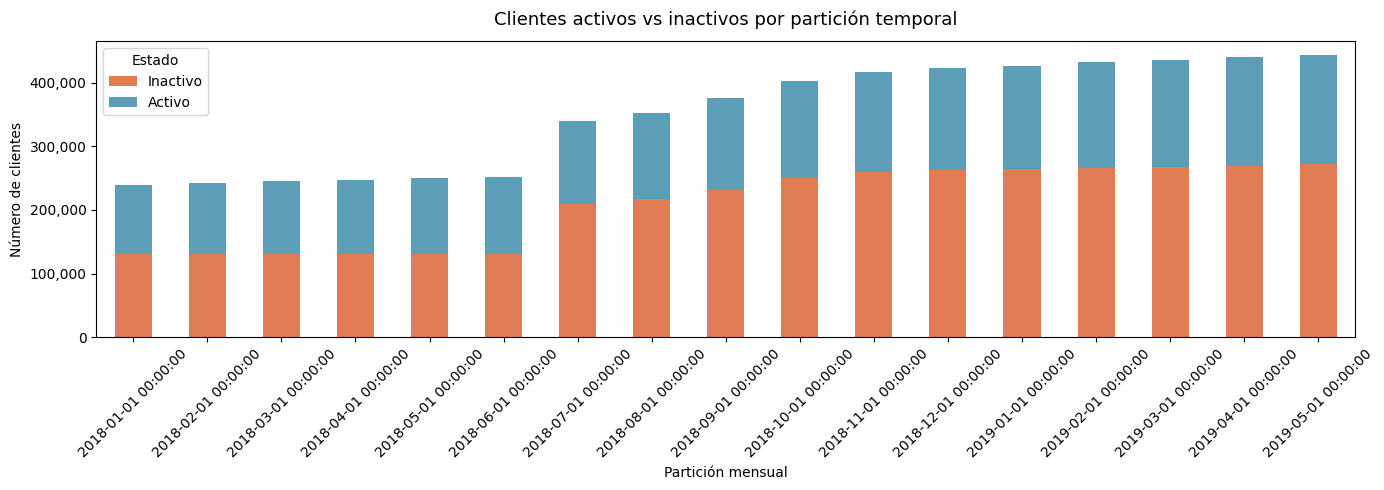

Porcentaje de clientes activos en la última partición: 38.7%


In [ ]:
df_plot = (
    df_commercial
    .groupby(['pk_partition', 'active_customer'])['pk_cid']
    .count()
    .unstack(fill_value=0)
)
df_plot.columns = ['Inactivo', 'Activo']

fig, ax = plt.subplots(figsize=(14, 5))
df_plot.plot(kind='bar', stacked=True, ax=ax, color=['#e07b54', '#5c9eb8'])
ax.set_title('Clientes activos vs inactivos por partición temporal', fontsize=13, pad=12)
ax.set_xlabel('Partición mensual')
ax.set_ylabel('Número de clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Estado')
plt.tight_layout()
plt.show()

# Porcentaje de actividad en la última partición
ultima = df_commercial[df_commercial['pk_partition'] == df_commercial['pk_partition'].max()]
pct_activo = ultima['active_customer'].mean() * 100
print(f'Porcentaje de clientes activos en la última partición: {pct_activo:.1f}%')

In [ ]:
# Última partición por cliente
df_commercial_last = (
    df_commercial
    .sort_values('pk_partition')
    .groupby('pk_cid')
    .last()
    .reset_index()
)

# Antigüedad en meses
df_commercial_last['pk_partition'] = pd.to_datetime(df_commercial_last['pk_partition'], format='%Y-%m')
df_commercial_last['entry_date']   = pd.to_datetime(df_commercial_last['entry_date'],   format='%Y-%m')

df_commercial_last['antiguedad_meses'] = (
    (df_commercial_last['pk_partition'].dt.year  - df_commercial_last['entry_date'].dt.year)  * 12 +
    (df_commercial_last['pk_partition'].dt.month - df_commercial_last['entry_date'].dt.month)
)

df_commercial_last.drop(columns=['pk_partition', 'entry_date'], inplace=True)

print('Estadísticas de antigüedad (meses):')
print(df_commercial_last['antiguedad_meses'].describe().round(1))

Estadísticas de antigüedad (meses):
count    456373.0
mean         23.4
std          14.4
min           0.0
25%           9.0
50%          21.0
75%          34.0
max          52.0
Name: antiguedad_meses, dtype: float64


---
## 4. Unión de datasets

Unimos los cuatro DataFrames usando `pk_cid` como clave.  
El punto de partida es **`df_sales2`** porque sólo queremos clientes que hayan tenido al menos una venta (estos son los que tiene sentido segmentar para acciones comerciales).  
El resto se une con `how='left'`, por lo que pueden aparecer nulos para clientes sin datos en alguna fuente.

In [ ]:
pd.set_option('display.max_columns', None)

df_final = (
    df_sales2
    .merge(df_sociodemographic, on='pk_cid', how='left')
    .merge(df_commercial_last,  on='pk_cid', how='left')
    .merge(df_customer_last,    on='pk_cid', how='left')
)

print(f'Dimensiones del dataset final: {df_final.shape[0]:,} clientes × {df_final.shape[1]} variables')
print('\nNulos por columna:')
nulos = df_final.isnull().sum()
print(nulos[nulos > 0].to_string())

Dimensiones del dataset final: 152,754 clientes × 29 variables

Nulos por columna:
region_code       43
salary         74307


In [ ]:
# Filtrar clientes: mayores de edad, no fallecidos y de España
mask = (
    (df_final['age'] >= 18) &
    (df_final['deceased'] == 0) &
    (df_final['country_id'] == 'ES')
)
df_final = df_final[mask].reset_index(drop=True)

print('Shape tras filtrado:', df_final.shape)

Shape tras filtrado: (152613, 29)


In [ ]:
#Creamos las columnas latitud y longitud para eliminar region_code.
# Diccionario: region_code -> (Latitud, Longitud)
geo_map = {
    1: (42.85, -2.67),   # Álava
    2: (38.99, -1.86),   # Albacete
    3: (38.34, -0.48),   # Alicante
    4: (36.84, -2.46),   # Almería
    5: (40.65, -4.70),   # Ávila
    6: (38.87, -6.97),   # Badajoz
    7: (39.57, 2.65),    # Baleares
    8: (41.38, 2.17),    # Barcelona
    9: (42.34, -3.70),   # Burgos
    10: (39.47, -6.37),  # Cáceres
    11: (36.52, -6.28),  # Cádiz
    12: (39.98, -0.05),  # Castellón
    13: (38.98, -3.92),  # Ciudad Real
    14: (37.88, -4.77),  # Córdoba
    15: (43.36, -8.41),  # A Coruña
    16: (40.07, -2.13),  # Cuenca
    17: (41.97, 2.82),   # Girona
    18: (37.17, -3.60),  # Granada
    19: (40.63, -3.16),  # Guadalajara
    20: (43.31, -1.98),  # Guipúzcoa
    21: (37.26, -6.94),  # Huelva
    22: (42.13, -0.40),  # Huesca
    23: (37.77, -3.78),  # Jaén
    24: (42.60, -5.57),  # León
    25: (41.61, 0.62),   # Lleida
    26: (42.46, -2.44),  # La Rioja
    27: (43.01, -7.55),  # Lugo
    28: (40.41, -3.70),  # Madrid
    29: (36.72, -4.42),  # Málaga
    30: (37.99, -1.13),  # Murcia
    31: (42.81, -1.64),  # Navarra
    32: (42.33, -7.86),  # Ourense
    33: (43.36, -5.84),  # Asturias
    34: (42.01, -4.52),  # Palencia
    35: (28.12, -15.43), # Las Palmas
    36: (42.43, -8.64),  # Pontevedra
    37: (40.96, -5.66),  # Salamanca
    38: (28.46, -16.25), # S.C. Tenerife
    39: (43.46, -3.80),  # Cantabria
    40: (40.94, -4.11),  # Segovia
    41: (37.38, -5.98),  # Sevilla
    42: (41.76, -2.46),  # Soria
    43: (41.11, 1.24),   # Tarragona
    44: (40.34, -1.10),  # Teruel
    45: (39.86, -4.02),  # Toledo
    46: (39.46, -0.37),  # Valencia
    47: (41.65, -4.72),  # Valladolid
    48: (43.26, -2.93),  # Vizcaya
    49: (41.50, -5.74),  # Zamora
    50: (41.64, -0.88),  # Zaragoza
    51: (35.88, -5.31),  # Ceuta
    52: (35.29, -2.93)   # Melilla
}

# Aplicar al DataFrame
df_final['latitud'] = df_final['region_code'].map(lambda x: geo_map.get(int(x), (None, None))[0])
df_final['longitud'] = df_final['region_code'].map(lambda x: geo_map.get(int(x), (None, None))[1])

In [ ]:
# Mapeo de Género
# Usamos 0 y 1 para los conocidos, y NaN para el resto
map_gender = {'Male': 0, 'Female': 1, 'Unknown': np.nan}
df_final['gender_code'] = df_final['gender'].map(map_gender)

# Mapeo de Segmento (jerarquía 1-3)
map_segment = {
    '01 - TOP': 1,
    '02 - PARTICULARES': 2,
    '03 - UNIVERSITARIO': 3,
    '00 - NO SEGMENTADO': np.nan
}
df_final['segment_code'] = df_final['segment'].map(map_segment)

In [ ]:
df_final['segment_code'].value_counts(normalize=True, dropna=False)*100

,proportion
segment_code,
3.0,51.495613
2.0,43.639795
1.0,3.749353
NaN,1.115239


In [ ]:
df_final['gender_code'].value_counts(normalize=True, dropna=False)*100

,proportion
gender_code,
1.0,52.196078
0.0,47.802612
NaN,0.001311


In [ ]:
# Borrar filas con nulos en las variables segment_code y gender_code
# (Esto eliminará ese 1.1% de segment_code y el 0.001% de gender)
df_final = df_final.dropna(subset=['segment_code', 'gender_code'])

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150909 entries, 0 to 151120
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pk_cid              150909 non-null  int64  
 1   product_ID          150909 non-null  object 
 2   net_margin          150909 non-null  float64
 3   country_id          150909 non-null  object 
 4   region_code         150909 non-null  float64
 5   gender              150909 non-null  object 
 6   age                 150909 non-null  int64  
 7   deceased            150909 non-null  int64  
 8   salary              78366 non-null   float64
 9   entry_channel       150909 non-null  object 
 10  active_customer     150909 non-null  float64
 11  segment             150909 non-null  object 
 12  antiguedad_meses    150909 non-null  int32  
 13  short_term_deposit  150909 non-null  int64  
 14  loans               150909 non-null  int64  
 15  mortgage            150909 non-null  in

In [ ]:
#Creacion de grupos de acuerdo a sus productos.
# 1. Definir el mapeo de grupos (basado en la lógica financiera)
grupos_productos = {
    'prod_ahorro_cuentas': ['em_account_p', 'em_account_pp', 'em_acount', 'emc_account', 'payroll_account'],
    'prod_financiacion': ['loans', 'mortgage', 'credit_card'],
    'prod_inversion_futuro': ['funds', 'securities', 'pension_plan', 'long_term_deposit', 'short_term_deposit'],
    'prod_operatividad': ['debit_card', 'payroll']
}

# 2. Crear las nuevas columnas mediante la suma de las originales
for nombre_grupo, columnas in grupos_productos.items():
    # Usamos fillna(0) por seguridad antes de sumar si hubiera nulos en productos
    df_final[nombre_grupo] = df_final[columnas].fillna(0).sum(axis=1)

# 3. Identificar todas las columnas originales para eliminarlas
todas_originales = [col for sublist in grupos_productos.values() for col in sublist]

# 4. Eliminar las 15 columnas originales
df_final.drop(columns=todas_originales, inplace=True)

# Verificar el resultado
print(f"Columnas actuales: {df_final.columns.tolist()}")

Columnas actuales: ['pk_cid', 'product_ID', 'net_margin', 'country_id', 'region_code', 'gender', 'age', 'deceased', 'salary', 'entry_channel', 'active_customer', 'segment', 'antiguedad_meses', 'total_products', 'latitud', 'longitud', 'gender_code', 'segment_code', 'prod_ahorro_cuentas', 'prod_financiacion', 'prod_inversion_futuro', 'prod_operatividad']


In [ ]:
#Eliminamos gender, country_id, segment, region_code
df_final.drop(columns=['gender', 'country_id', 'segment', 'deceased', 'entry_channel'], inplace=True)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150909 entries, 0 to 151120
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   pk_cid                 150909 non-null  int64  
 1   product_ID             150909 non-null  object 
 2   net_margin             150909 non-null  float64
 3   region_code            150909 non-null  float64
 4   age                    150909 non-null  int64  
 5   salary                 78366 non-null   float64
 6   active_customer        150909 non-null  float64
 7   antiguedad_meses       150909 non-null  int32  
 8   total_products         150909 non-null  int64  
 9   latitud                150909 non-null  float64
 10  longitud               150909 non-null  float64
 11  gender_code            150909 non-null  float64
 12  segment_code           150909 non-null  float64
 13  prod_ahorro_cuentas    150909 non-null  int64  
 14  prod_financiacion      150909 non-null  i

---
## 5. Tratamiento de valores nulos

Dos columnas presentan nulos:

| Variable | Nulos | Estrategia | Justificación |
|---|---|---|---|
| `salary` | ~74k (~49%) | **Imputación KNN** | El salario está correlacionado con región, edad y segmento; KNN usa esas relaciones para estimar el valor |
| `region_code` | 43 (<0.1%) | **Eliminación** | Sin región no podemos imputar el salario ni contextualizar al cliente; es una pérdida despreciable |

**KNN Imputer** con `n_neighbors=5`: para cada cliente sin salario, busca los 5 clientes más similares (por región, género, edad y segmento) y calcula la media de sus salarios.

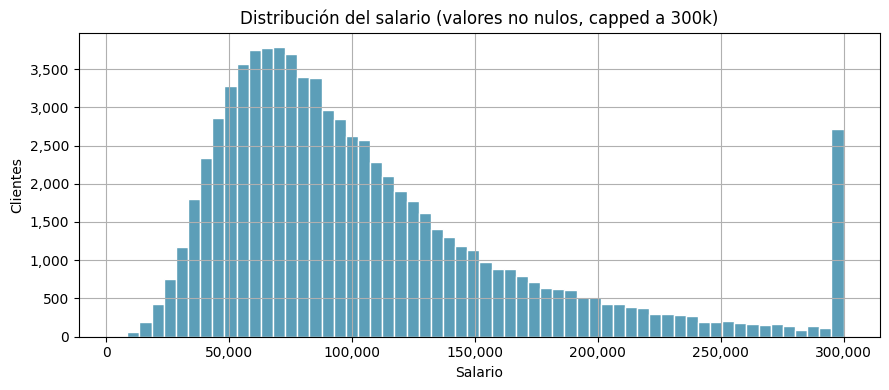

In [ ]:
# Distribución del salario antes de imputar (sólo en los que tienen valor)
fig, ax = plt.subplots(figsize=(9, 4))
df_final['salary'].dropna().clip(upper=300_000).hist(bins=60, ax=ax, color='#5c9eb8', edgecolor='white')
ax.set_title('Distribución del salario (valores no nulos, capped a 300k)', fontsize=12)
ax.set_xlabel('Salario')
ax.set_ylabel('Clientes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Antes de aplicar KNN para imputación, se trataron los valores extremos (outliers) en **"salary"** mediante **winsorización** y se escalaron las variables, ya que el algoritmo se basa en distancias entre observaciones, por lo que el pipeline quedaría así:
1. Tratar outliers
2. Seleccionar variable "salary"
3. Escalar la variable
4. Aplicar KNN imputer

El preprocesamiento es clave, ya que KNN es altamente sensible a la escala y a los valores extremos.

In [ ]:
# 1. Exploramos primero la variable "salary":

df_final["salary"].describe()

,salary
count,7.836600e+04
mean,1.151614e+05
std,2.067053e+05
min,3.731790e+03
25%,6.215425e+04
50%,8.918259e+04
75%,1.316411e+05
max,2.889440e+07


In [ ]:
# 2. Calculamos los límites (percentiles):

percent_01 = df_final["salary"].quantile(0.01)
percent_99 = df_final["salary"].quantile(0.99)

In [ ]:
# 3. Vemos los outliers que hay:

outliers_high = (df_final["salary"] > percent_99).sum()
outliers_low = (df_final["salary"] < percent_01).sum()

print("Outliers altos:", outliers_high)
print("Outliers bajos:", outliers_low)

Outliers altos: 784
Outliers bajos: 784


- Se aplicó "winsorización" a la variable salary, limitando los valores al percentil 1 y 99 para reducir el impacto de outliers:

In [ ]:
# 4. Winsorización (capado):

df_final["salary"] = df_final["salary"].clip(lower=percent_01, upper=percent_99)

In [ ]:
# 5. Comprobamos el resultado:

df_final["salary"].quantile([0.01, 0.25, 0.5, 0.75, 0.9, 0.99])

,salary
0.01,24225.340350
0.25,62154.247500
0.50,89182.590000
0.75,131641.087500
0.90,195520.710000
0.99,466825.562025


Tras la winsorización, la variable "salary" presenta una distribución más estable, eliminando valores extremos irreales y manteniendo una variabilidad coherente para su uso en el modelo.

- Se analiza la distribución del salario tras limpieza de datos, eliminando valores nulos para entender su comportamiento antes de la imputación:

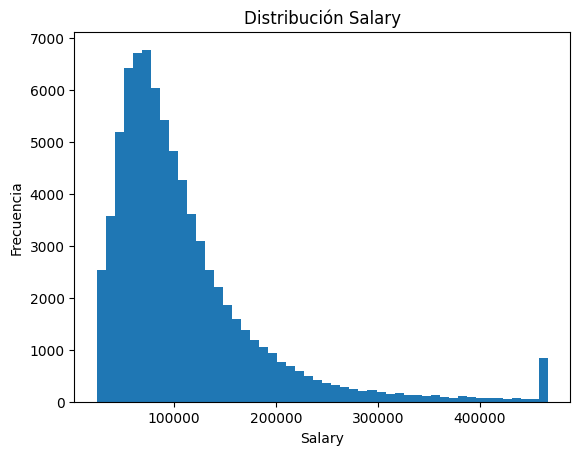

In [ ]:
#Eliminamos los nulos solo para poder visualizar la variable creando un nuevo df "salary_data".
#El "df_final" es el que se seguirá utilizando para la imputación KNN y entrenar el modelo.

salary_data = df_final["salary"].dropna()

import matplotlib.pyplot as plt

plt.figure()
plt.hist(salary_data, bins=50)

plt.title("Distribución Salary")
plt.xlabel("Salary")
plt.ylabel("Frecuencia")

plt.show()

La distribución muestra una asimetría positiva típica en variables de ingresos, con mayor concentración en valores medios y una cola hacia salarios altos.

### 5.1 Escalado de dataframe

In [ ]:

# 1. Filtramos y quitamos la columna (esto está bien)
df_final_pre = df_final.select_dtypes(include='number').drop(columns=['pk_cid'], errors='ignore')
# 2. Escalamos (devuelve un array de NumPy)
scaler = StandardScaler()
df_final_scaled_array = scaler.fit_transform(df_final_pre)


In [ ]:
# 3. Reconstruimos el DataFrame usando las columnas de df_final_pre
df_final_scaled = pd.DataFrame(
    df_final_scaled_array,
    columns = df_final_pre.columns,
    index = df_final_pre.index  # Es buena práctica mantener el índice original
)

In [ ]:
df_final_scaled

,net_margin,region_code,age,salary,active_customer,antiguedad_meses,total_products,latitud,longitud,gender_code,segment_code,prod_ahorro_cuentas,prod_financiacion,prod_inversion_futuro,prod_operatividad
0,-0.406142,0.100293,1.972349,NaN,-1.390326,-1.121013,-1.380028,0.199346,-0.056341,-1.044117,-0.846279,-2.379724,-0.153236,-0.377525,-0.527660
1,-0.392435,-1.360400,2.790959,NaN,0.719256,-0.779086,-0.434442,0.543136,1.541316,0.957747,-2.598940,0.002099,-0.153236,-0.377525,-0.527660
2,-0.376058,0.100293,1.897930,NaN,0.719256,-0.522640,0.511144,0.199346,-0.056341,-1.044117,-0.846279,2.383922,-0.153236,-0.377525,-0.527660
3,-0.410847,0.100293,1.600254,-0.100184,0.719256,0.503141,1.456729,0.199346,-0.056341,-1.044117,-0.846279,0.002099,-0.153236,2.327696,1.245215
4,-0.038163,0.100293,3.237474,NaN,0.719256,2.982113,3.347901,0.199346,-0.056341,0.957747,-0.846279,2.383922,-0.153236,5.032918,1.245215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151116,-0.411481,0.100293,0.335129,NaN,0.719256,-1.121013,-0.434442,0.199346,-0.056341,0.957747,-0.846279,0.002099,-0.153236,-0.377525,-0.527660
151117,1.590826,0.246362,-0.185805,NaN,0.719256,-1.121013,1.456729,-0.658356,0.643144,-1.044117,-0.846279,0.002099,-0.153236,2.327696,1.245215
151118,-0.410621,0.173328,1.897930,NaN,0.719256,-1.121013,-0.434442,-1.108473,-0.252306,0.957747,-0.846279,0.002099,-0.153236,-0.377525,-0.527660
151119,1.364854,1.780089,1.451415,NaN,0.719256,-1.121013,1.456729,-1.406188,-0.494540,0.957747,-0.846279,0.002099,-0.153236,2.327696,1.245215


In [ ]:
cols = ['latitud', 'longitud', 'gender_code', 'age', 'segment_code', 'salary']

df_impute = df_final_scaled[cols].copy()


imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_impute)

df_final_scaled['salary'] = df_imputed[:, cols.index('salary')]

In [ ]:
print(f'\nNulos restantes: {df_final_scaled.isnull().sum().sum()}')


Nulos restantes: 0


In [ ]:
# 1. Revertimos la escala (esto devuelve un array de NumPy)
df_original_scale_array = scaler.inverse_transform(df_final_scaled)

# 2. Lo convertimos de nuevo a DataFrame de Pandas
df_final_desescalado = pd.DataFrame(
    df_original_scale_array,
    columns=df_final_scaled.columns,
    index=df_final_scaled.index
)

In [ ]:
df_final_desescalado.describe().T

,count,mean,std,min,25%,50%,75%,max
net_margin,150909.0,964.158018,2210.458249,2.670000e+01,6.430000e+01,7.490000e+01,1.329000e+02,18649.9000
region_code,150909.0,26.626775,13.692181,1.000000e+00,1.500000e+01,2.800000e+01,3.600000e+01,52.0000
age,150909.0,32.496736,13.437454,1.900000e+01,2.100000e+01,2.800000e+01,4.000000e+01,102.0000
salary,150909.0,118243.518458,77405.441251,2.422508e+04,6.992590e+04,9.542984e+04,1.393494e+05,466943.7915
active_customer,150909.0,0.659053,0.474029,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.0000
antiguedad_meses,150909.0,14.114055,11.698436,1.000000e+00,7.000000e+00,9.000000e+00,1.800000e+01,52.0000
total_products,150909.0,1.459442,1.057549,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,9.0000
latitud,150909.0,39.847547,2.821502,2.812000e+01,3.887000e+01,4.041000e+01,4.138000e+01,43.4600
longitud,150909.0,-3.492996,3.674144,-1.625000e+01,-5.660000e+00,-3.700000e+00,-8.800000e-01,2.8200
gender_code,150909.0,0.521573,0.499536,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.0000


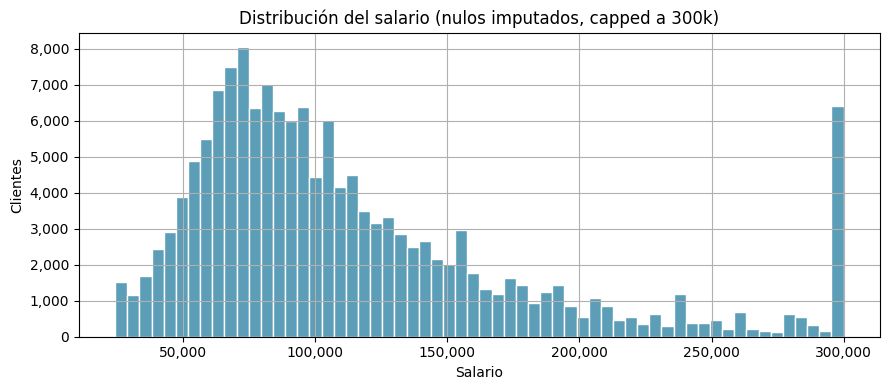

In [ ]:
# Distribución del salario antes de imputar (sólo en los que tienen valor)
fig, ax = plt.subplots(figsize=(9, 4))
df_final_desescalado['salary'].dropna().clip(upper=300_000).hist(bins=60, ax=ax, color='#5c9eb8', edgecolor='white')
ax.set_title('Distribución del salario (nulos imputados, capped a 300k)', fontsize=12)
ax.set_xlabel('Salario')
ax.set_ylabel('Clientes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


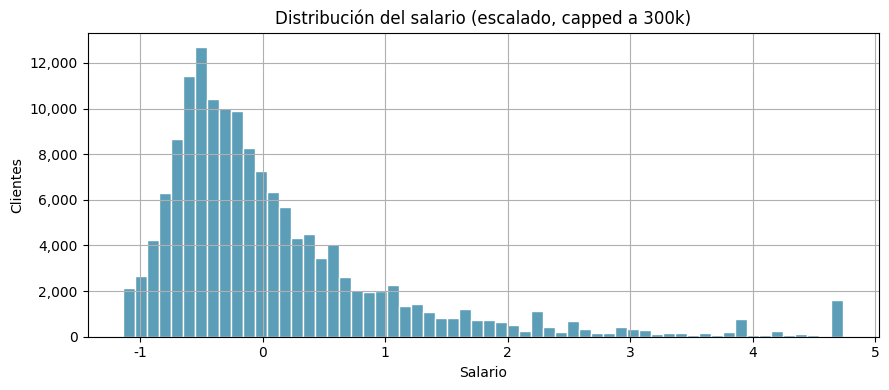

In [ ]:
# Distribución del salario antes de imputar (sólo en los que tienen valor)
fig, ax = plt.subplots(figsize=(9, 4))
df_final_scaled['salary'].dropna().clip(upper=8).hist(bins=60, ax=ax, color='#5c9eb8', edgecolor='white')
ax.set_title('Distribución del salario (escalado, capped a 300k)', fontsize=12)
ax.set_xlabel('Salario')
ax.set_ylabel('Clientes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


---
## 6. K-Means Clustering

### Preprocesado previo al clustering

K-Means mide distancias euclídeas entre puntos. Si una variable tiene rango 0–200k (salario) y otra 0–1 (producto binario), el salario dominaría completamente la distancia.  
Por eso aplicamos **`StandardScaler`**: transforma cada variable a **media 0 y desviación estándar 1**.

### Número de clusters: k = 7

Se eligió k=7 tras analizar el codo de inercia (suma de distancias cuadráticas al centroide).

### Parámetros del modelo

- `n_clusters=7`: número de grupos
- `random_state=42`: semilla para reproducibilidad
- `n_init=10`: el algoritmo se ejecuta 10 veces con centroides iniciales aleatorios distintos y se conserva la mejor solución (menor inercia)

In [ ]:
# Entrenamiento
km_final = KMeans(n_clusters=7, random_state=42, n_init=10)
df_final_desescalado['cluster'] = km_final.fit_predict(df_final_scaled)

print('\nInertia (suma de distancias cuadráticas al centroide):', f'{km_final.inertia_:,.0f}')
print('\nDistribución de clientes por cluster:')
dist = df_final_desescalado['cluster'].value_counts().sort_index()
for c, n in dist.items():
    pct = n / len(df_final) * 100
    print(f'  Cluster {c}: {n:>7,} clientes ({pct:.1f}%)')


Inertia (suma de distancias cuadráticas al centroide): 1,255,110

Distribución de clientes por cluster:
  Cluster 0:   4,665 clientes (3.1%)
  Cluster 1:  28,295 clientes (18.7%)
  Cluster 2:  15,885 clientes (10.5%)
  Cluster 3:  44,348 clientes (29.4%)
  Cluster 4:   3,474 clientes (2.3%)
  Cluster 5:  13,831 clientes (9.2%)
  Cluster 6:  40,411 clientes (26.8%)


### Distribución de clientes por cluster

Un buen clustering no requiere clusters de igual tamaño, pero clusters **extremadamente pequeños** (como el cluster 3 con 14 clientes y el cluster 6 con 2) merecen atención especial: pueden representar outliers o perfiles muy atípicos.

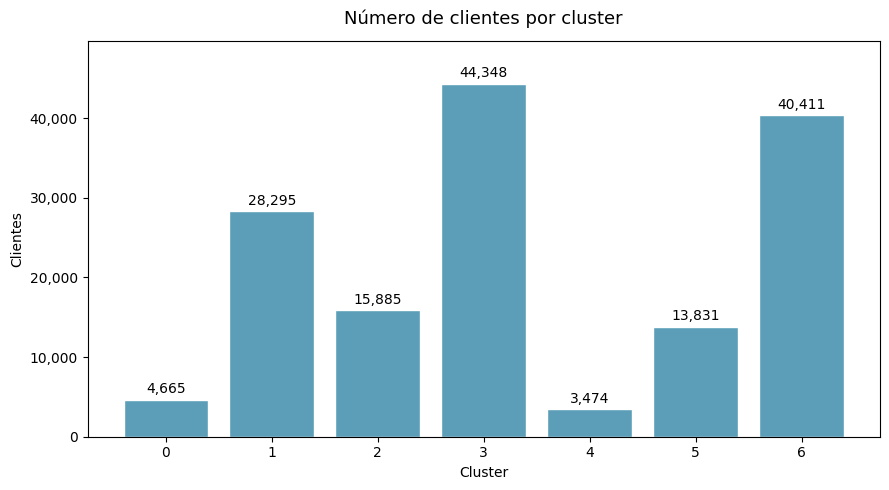

Nota: barras naranjas = clusters muy pequeños (posibles outliers)


In [ ]:
dist = df_final_desescalado['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dist.index.astype(str), dist.values,
              color=['#e07b54' if v < 100 else '#5c9eb8' for v in dist.values],
              edgecolor='white')

for bar, n in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f'{n:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Número de clientes por cluster', fontsize=13, pad=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, dist.max() * 1.12)
plt.tight_layout()
plt.show()

print('Nota: barras naranjas = clusters muy pequeños (posibles outliers)')

---
## 7. Análisis de los clusters

### 7.1 Perfil estadístico de cada cluster

La tabla siguiente muestra la **media** de las principales variables por cluster.  
Leer horizontalmente: permite comparar cómo difiere cada segmento.  
El gradiente de color ayuda a identificar qué cluster tiene los valores más altos (oscuro) y más bajos (claro) en cada variable.

In [ ]:
vars_perfil = ['age', 'salary', 'net_margin', 'antiguedad_meses',
               'active_customer', 'total_products']

perfil = df_final_desescalado.groupby('cluster')[vars_perfil].mean().round(2)

# Añadir tamaño del cluster
perfil.insert(0, 'n_clientes', df_final_desescalado.groupby('cluster').size())

perfil.style \
    .format({'n_clientes': '{:,.0f}', 'age': '{:.1f}', 'salary': '{:,.0f}',
             'net_margin': '{:,.2f}', 'antiguedad_meses': '{:.0f}',
             'active_customer': '{:.2f}', 'total_products': '{:.2f}'}) \
    .background_gradient(cmap='Blues', subset=vars_perfil, axis=0) \
    .set_caption('Media de variables clave por cluster')

,n_clientes,age,salary,net_margin,antiguedad_meses,active_customer,total_products
cluster,,,,,,,
0,"4,665",32.4,"94,682",805.74,13,0.59,1.34
1,"28,295",22.7,"126,225",232.05,10,1.00,1.11
2,"15,885",33.8,"110,655","1,642.81",36,0.91,1.66
3,"44,348",24.5,"119,315",180.85,9,0.00,0.83
4,"3,474",41.3,"120,660","2,130.88",29,1.00,3.91
5,"13,831",36.8,"117,140","5,218.72",22,1.00,3.73
6,"40,411",45.4,"117,351",531.44,10,0.91,1.34


### 7.2 Penetración de categorías de producto por cluster

Los 15 productos individuales están agrupados en **4 categorías** en `df_final`:

| Variable | Productos incluidos |
|---|---|
| `prod_ahorro_cuentas` | Cuentas corrientes, depósitos a corto plazo, cuenta nómina… |
| `prod_financiacion` | Préstamos, hipoteca, tarjeta de crédito… |
| `prod_inversion_futuro` | Fondos, valores, depósito a largo plazo, plan de pensiones… |
| `prod_operatividad` | Tarjeta débito, cuenta em, domiciliación nómina… |

El heatmap muestra el **valor medio** de cada categoría por cluster. Cuanto más oscuro, mayor penetración.

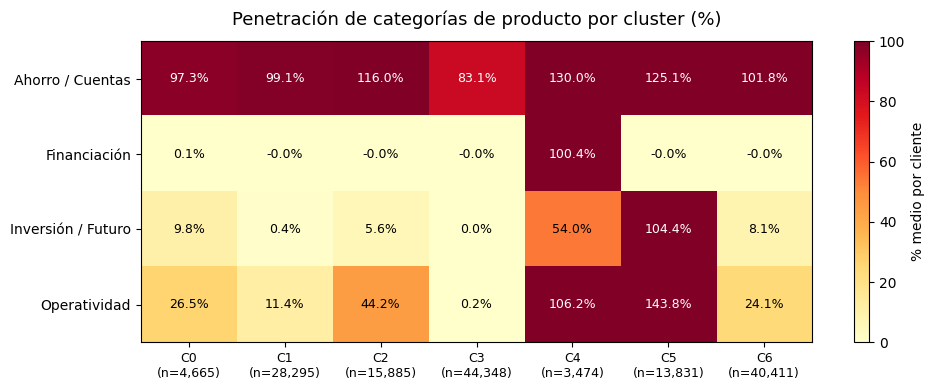

In [ ]:
#Categorías de productos disponibles en df_final_desescalado
prods_cat = ['prod_ahorro_cuentas', 'prod_financiacion',
             'prod_inversion_futuro', 'prod_operatividad']

labels_cat = {
    'prod_ahorro_cuentas'  : 'Ahorro / Cuentas',
    'prod_financiacion'    : 'Financiación',
    'prod_inversion_futuro': 'Inversión / Futuro',
    'prod_operatividad'    : 'Operatividad',
}

prod_pct = df_final_desescalado.groupby('cluster')[prods_cat].mean() * 100

n_clusters = prod_pct.shape[0]
n_prods    = prod_pct.shape[1]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prod_pct.T.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)

cluster_labels = [
    f'C{c}\n(n={df_final_desescalado["cluster"].value_counts()[c]:,})'
    for c in prod_pct.index
]
ax.set_xticks(range(n_clusters))
ax.set_xticklabels(cluster_labels, fontsize=9)
ax.set_yticks(range(n_prods))
ax.set_yticklabels([labels_cat[p] for p in prods_cat], fontsize=10)
ax.set_title('Penetración de categorías de producto por cluster (%)', fontsize=13, pad=12)

for ci, c in enumerate(prod_pct.index):
    for pi, p in enumerate(prods_cat):
        val = prod_pct.loc[c, p]
        ax.text(ci, pi, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white' if val > 60 else 'black')

plt.colorbar(im, ax=ax, label='% medio por cliente')
plt.tight_layout()
plt.show()

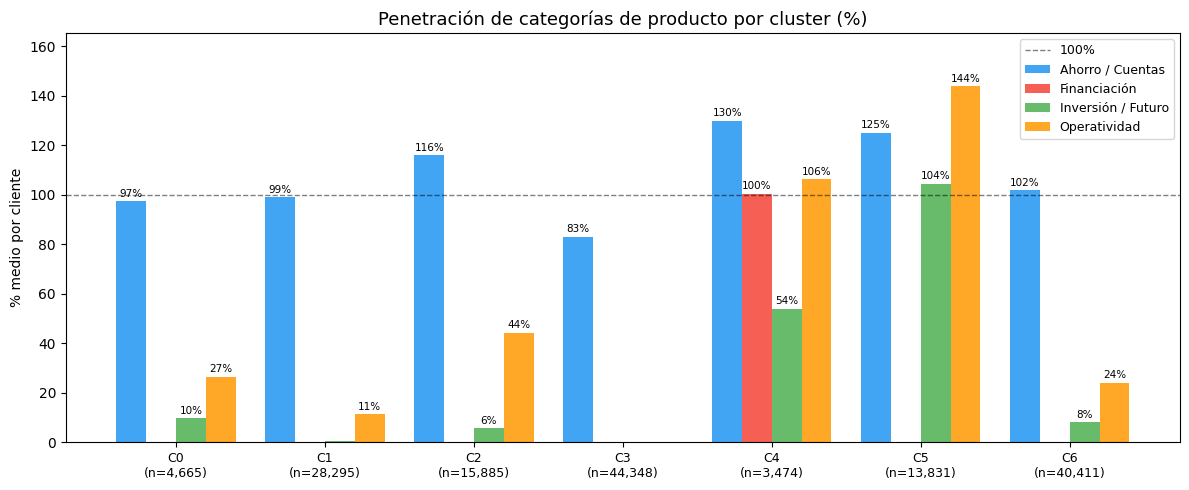

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(n_clusters)
width = 0.2
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for i, (col, label) in enumerate(labels_cat.items()):
    vals = prod_pct[col].values
    bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=7.5)

ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5, label='100%')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cluster_labels, fontsize=9)
ax.set_ylabel('% medio por cliente')
ax.set_title('Penetración de categorías de producto por cluster (%)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, prod_pct.values.max() * 1.15)
plt.tight_layout()
plt.show()


### 7.3 Comparativa de variables continuas

Los boxplots muestran la distribución completa (no solo la media) de las variables más relevantes para el negocio.

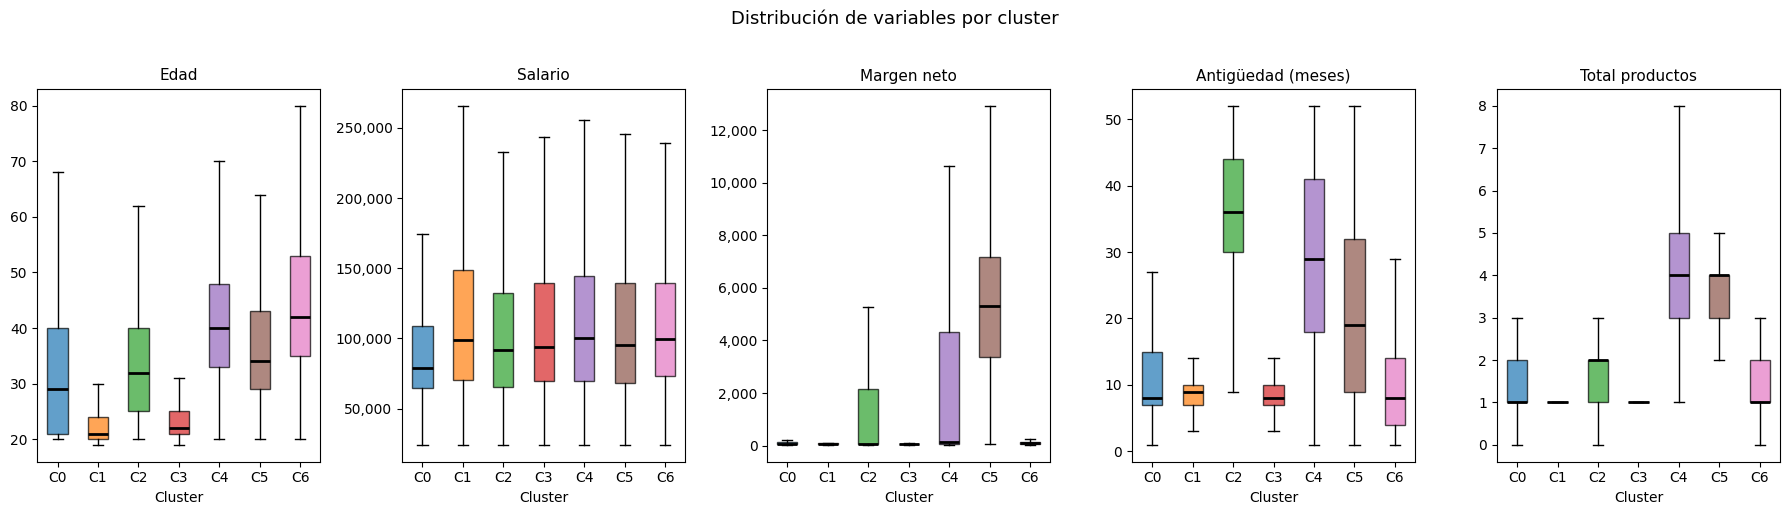

In [ ]:
vars_box = ['age', 'salary', 'net_margin', 'antiguedad_meses', 'total_products']
titles   = ['Edad', 'Salario', 'Margen neto', 'Antigüedad (meses)', 'Total productos']

fig, axes = plt.subplots(1, len(vars_box), figsize=(18, 5))

for ax, var, title in zip(axes, vars_box, titles):
    data_by_cluster = [df_final_desescalado.loc[df_final_desescalado['cluster'] == c, var].dropna() for c in range(7)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    colors = plt.cm.tab10.colors[:7]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_xticklabels([f'C{i}' for i in range(7)])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Distribución de variables por cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 8. Interpretación de los clusters

El análisis combina el perfil financiero medio (edad, salario, margen neto, antigüedad, actividad, productos) con la penetración de categorías de producto para construir una caracterización completa de cada segmento.

---

### 8.1 Perfiles por cluster

| Cluster | n | Perfil técnico | Edad | Salario medio | Margen neto | Productos / cliente |
| :--- | ---: | :--- | ---: | ---: | ---: | ---: |
| **C0** | 4,665 | Rentabilidad y vinculación media | 32.4 | $94,682 | $805.74 | 1.34 |
| **C1** | 28,295 | Jóvenes activos / baja vinculación | 22.7 | $126,225 | $232.05 | 1.11 |
| **C2** | 15,885 | Alta antigüedad / vinculación media | 33.8 | $110,655 | $1,642.81 | 1.66 |
| **C3** | 44,348 | Jóvenes inactivos / baja vinculación | 24.5 | $119,315 | $180.85 | 0.83 |
| **C4** | 3,474 | Maduros con alta vinculación | 41.3 | $120,660 | $2,130.88 | 3.91 |
| **C5** | 13,831 | Máxima rentabilidad y vinculación | 36.8 | $117,140 | $5,218.72 | 3.73 |
| **C6** | 40,411 | Mayor edad con vinculación media-baja | 45.4 | $117,351 | $531.44 | 1.34 |

---

### 8.2 Penetración de categorías de producto

| Cluster | Ahorro / Cuentas | Financiación | Inversión / Futuro | Operatividad |
|---------|------------------|--------------|--------------------|--------------|
| **C0** | 97% | ~0% | 10% | 27% |
| **C1** | 99% | ~0% | ~0% | 11% |
| **C2** | **116%** | ~0% | 6% | 44% |
| **C3** | 83% | ~0% | ~0% | ~0% |
| **C4** | **130%** | **100%** | 54% | **106%** |
| **C5** | **125%** | ~0% | **104%** | **144%** |
| **C6** | **102%** | ~0% | 8% | 24% |

> Valores >100% indican más de un producto de esa categoría por cliente

 ---

### 8.3 Análisis detallado por cluster

#### C5 — *"Máxima Rentabilidad y Vinculación"* ⭐⭐⭐⭐⭐
- **Margen más alto de toda la cartera**: $5,218.72 — el triple que el siguiente grupo de alta vinculación
- Alta diversificación de producto (3.73 por cliente): la combinación de productos es la causa directa del margen, no el nivel salarial
- Perfil de edad equilibrado (36.8 años) con capacidad de consumo máxima en productos complejos
- **Acción**: Retención prioritaria, gestión personalizada, productos exclusivos

#### C4 — *"Maduros con Alta Vinculación"* ⭐⭐⭐⭐⭐
- **Mayor diversificación de producto de toda la cartera**: 3.91 productos por cliente, relación bancaria consolidada y uso activo en múltiples dimensiones
- Alta edad media (41.3 años) y salario elevado — perfil ideal para seguros, planificación y refinanciación
- Segundo mayor margen de la cartera ($2,130.88): la vinculación multidimensional explica directamente el resultado
- **Acción**: Seguros vinculados, refinanciación, productos de ahorro para amortización

#### C2 — *"Alta Antigüedad / Vinculación Media"* ⭐⭐⭐⭐
- Clientes consolidados con alta confianza — mayor antigüedad estimada de la cartera
- Margen positivo ($1,642.81) pero vinculación aún por debajo del potencial: solo 1.66 productos por cliente
- **Oportunidad clara**: incorporar inversión y operatividad podría elevarlos al nivel de C4/C5; el perfil de edad y antigüedad lo hace viable
- **Acción**: Cross-selling de fondos, planes de pensiones o ahorro a plazo

#### C6 — *"Mayor Edad con Vinculación Media-Baja"* ⭐⭐
- 40,411 clientes, mayor edad media de la cartera (45.4 años) pero con baja vinculación: 1.34 productos por cliente
- **El mayor gap entre potencial de vida y uso de productos**: perfil ideal para inversión a largo plazo, seguros y planificación patrimonial que no consume actualmente
- Salario similar a la media de la cartera ($117,351) — la capacidad financiera existe, falta la propuesta de valor
- **Acción**: Campaña de reactivación con productos adaptados a su etapa vital (inversión, seguros, planificación)

#### C0 — *"Rentabilidad y Vinculación Media"* ⭐⭐⭐
- Segmento pequeño (4,665 clientes) pero con margen positivo ($805.74) y vinculación moderada — superior a C1 y C3
- Salario más bajo de la cartera ($94,682), perfil joven (32.4 años): hay un embrión de engagement que se puede desarrollar antes de que derive en churn
- Oportunidad de crecimiento natural a medida que el cliente avanza en su etapa vital y capacidad de ahorro
- **Acción**: Onboarding mejorado, oferta de primer producto de inversión, incentivos de actividad

#### C1 — *"Jóvenes Activos / Baja Vinculación"* ⭐
- **28,295 clientes** con el salario medio más alto de la cartera ($126,225) pero margen casi nulo ($232.05) — no usan el banco
- Edad muy joven (22.7 años), recién incorporados, actividad mínima (1.11 productos por cliente)
- **Hipótesis**: banco secundario o clientes captados sin propuesta de valor clara
- **Acción**: Activación urgente o revisión del coste de servicio vs. LTV esperado

#### C3 — *"Jóvenes Inactivos / Baja Vinculación"* ⭐
- **44,348 clientes (~29% de la cartera)** con menos de 1 producto de media (0.83) y el margen más bajo de toda la cartera ($180.85)
- Clientes jóvenes (24.5 años) sin engagement real: el coste de servicio probablemente supera el margen generado
- **Hipótesis**: clientes captados masivamente sin segmentación o banco puramente instrumental (nómina, recibos)
- **Acción**: Segmentación interna, propuesta de valor diferenciada, evaluación de rentabilidad real vs. coste de servicio